In [3]:
#https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data
!pip install kaggle

In [4]:
import os
import shutil

source = r"C:\Users\ameya\Downloads\kaggle.json"  
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

shutil.copy(source, os.path.join(kaggle_dir, "kaggle.json"))
os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)


In [5]:
##!kaggle competitions download -c house-prices-advanced-regression-techniques

In [6]:
import zipfile

with zipfile.ZipFile('C:/Users/ameya/Downloads/house-prices-advanced-regression-techniques.zip', 'r') as zip_ref:
    zip_ref.extractall('house-prices-advanced-regression-techniques')

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df = df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'])
df = df.fillna(df.median(numeric_only=True))
df = df.select_dtypes(include=['int64', 'float64'])


In [16]:
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [34]:
huber = HuberRegressor()
huber.fit(X_train_scaled, y_train)
y_pred_huber = huber.predict(X_test_scaled)

In [36]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [38]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

📈 Linear Regression
MSE: 1356957853.3167758
MAE: 22975.85650915436

🛡️ Huber Regressor
MSE: 1279534445.4156992
MAE: 20910.823933669508

🔒 Ridge Regression
MSE: 1356902150.4380693
MAE: 22973.061649100327

🧹 Lasso Regression
MSE: 1356955720.1343646
MAE: 22975.879007958723


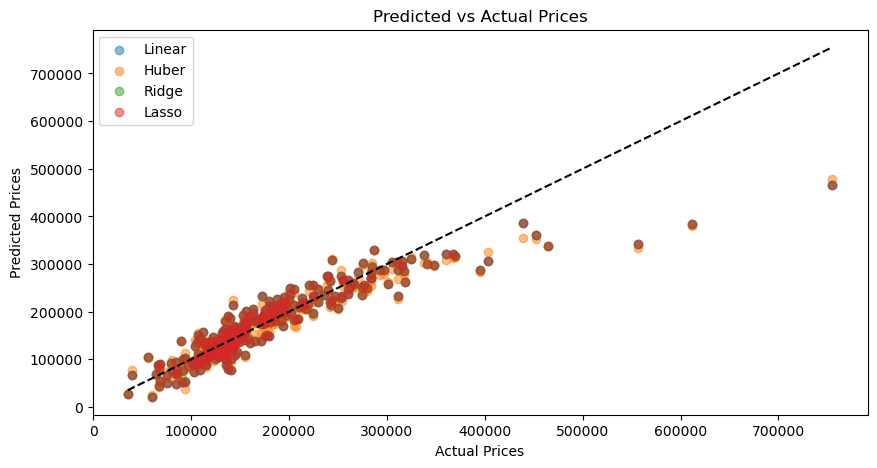

In [40]:
print("📈 Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("\n🛡️ Huber Regressor")
print("MSE:", mean_squared_error(y_test, y_pred_huber))
print("MAE:", mean_absolute_error(y_test, y_pred_huber))

print("\n🔒 Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

print("\n🧹 Lasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

# 📉 Step 7: Visualize Predictions
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, label="Linear")
plt.scatter(y_test, y_pred_huber, alpha=0.5, label="Huber")
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label="Ridge")
plt.scatter(y_test, y_pred_lasso, alpha=0.5, label="Lasso")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.title("Predicted vs Actual Prices")
plt.show()

C:\Users\ameya\AppData\Local\Temp\ipykernel_14344\177530256.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ameya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


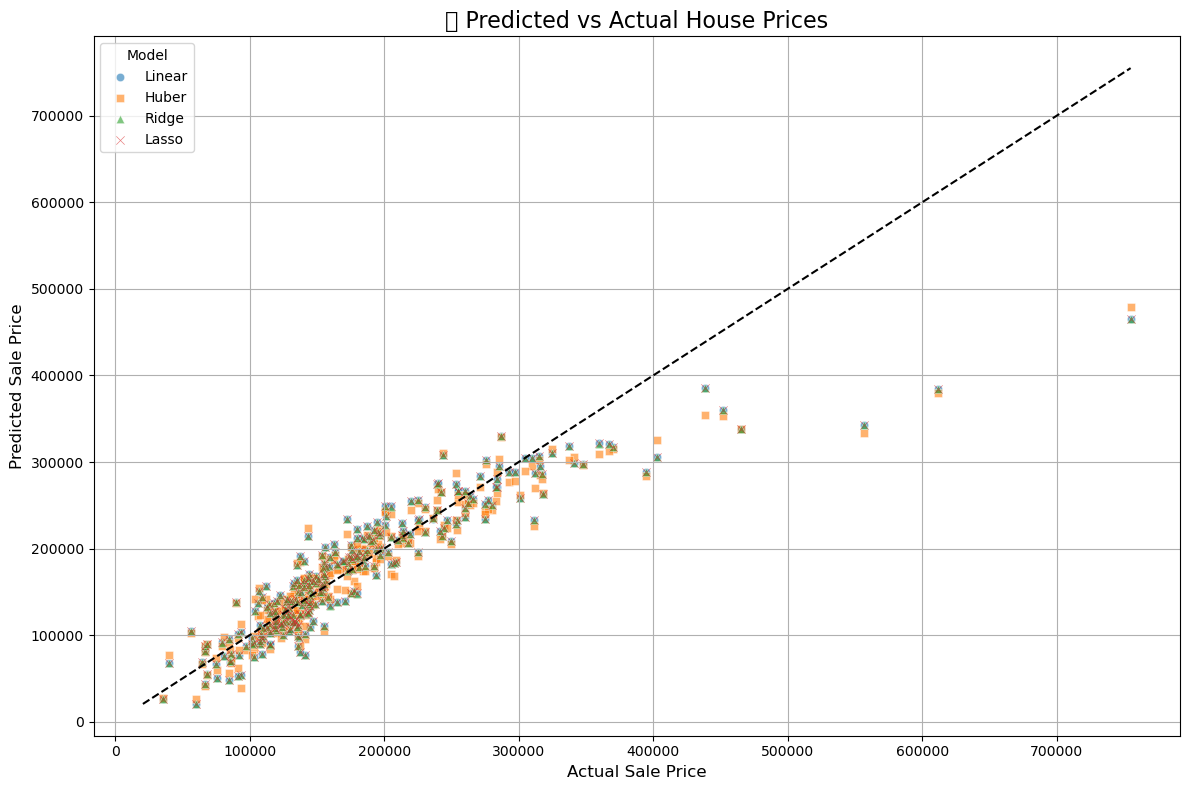

In [42]:
import seaborn as sns

plt.figure(figsize=(12, 8))

# Scatter for each model
sns.scatterplot(x=y_test, y=y_pred_lr, label="Linear", alpha=0.6, marker='o')
sns.scatterplot(x=y_test, y=y_pred_huber, label="Huber", alpha=0.6, marker='s')
sns.scatterplot(x=y_test, y=y_pred_ridge, label="Ridge", alpha=0.6, marker='^')
sns.scatterplot(x=y_test, y=y_pred_lasso, label="Lasso", alpha=0.6, marker='x')

# Diagonal reference line (perfect prediction)
max_val = max(y_test.max(), y_pred_lr.max())
min_val = min(y_test.min(), y_pred_lr.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)

plt.xlabel("Actual Sale Price", fontsize=12)
plt.ylabel("Predicted Sale Price", fontsize=12)
plt.title("📈 Predicted vs Actual House Prices", fontsize=16)
plt.legend(title="Model", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()
